## PCL - Tabeer Asif



In [ ]:
!pip install nlpaug
!pip install sacremoses


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 53.5 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/nlp-pcl-cw-main

Mounted at /content/drive
/content/drive/MyDrive/nlp-pcl-cw-main


In [2]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import transformers
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import pipeline, RobertaModel, AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, get_scheduler, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch import cuda
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE, RandomOverSampler
# import nlpaug.augmenter.word as naw
# import sacremoses
import nltk
import math
import random
from dataset.dont_patronize_me import DontPatronizeMe

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [3]:
device = 'cuda' if cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Split train set into training + validation (internal dev) sets

In [5]:
train_df = pd.read_csv("train_data/train_set.csv")
train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['label'],
    random_state=42
)
print(train_df_split.shape)
print(val_df.shape)
val_df.to_csv("train_data/val_set.csv", index=False)


(7118, 7)
(1257, 7)


### Data Augmentation through Back Translation - French/English

In [ ]:
# # ----- Backtranslation setup (English -> French -> English) -----
# bt_augmenter = naw.BackTranslationAug(
#     from_model_name="Helsinki-NLP/opus-mt-en-fr",
#     to_model_name="Helsinki-NLP/opus-mt-fr-en",
#     device="cuda",
#     max_length=256
# )

# # ----- Select minority class examples (label = 1) from training split -----
# minority_df = train_df_split.loc[train_df_split["label"] == 1].copy()
# minority_df = minority_df.dropna(subset=["text"])

# minority_texts = minority_df["text"].tolist()

# generated_texts = []
# augmentation_batch_size = 32

# # ----- Perform batch backtranslation -----
# for start_idx in range(0, len(minority_texts), augmentation_batch_size):
#     current_batch = minority_texts[start_idx:start_idx + augmentation_batch_size]

#     translated_batch = bt_augmenter.augment(current_batch)

#     # Ensure output is always a list
#     if isinstance(translated_batch, str):
#         translated_batch = [translated_batch]

#     generated_texts.extend(translated_batch)

# # ----- Clean augmented outputs -----
# generated_texts = [
#     str(sentence).strip()
#     for sentence in generated_texts
#     if sentence is not None and len(str(sentence).strip()) > 0
# ]

# # ----- Align sizes safely -----
# usable_length = min(len(minority_df), len(generated_texts))

# augmented_samples = minority_df.iloc[:usable_length].copy()
# augmented_samples["text"] = generated_texts[:usable_length]

# # ----- Combine augmented data with original training split -----
# expanded_train_df = pd.concat(
#     [train_df_split, augmented_samples],
#     ignore_index=True
# )

# print("Class distribution after augmentation:")
# print(expanded_train_df["label"].value_counts())


# train_df_split = expanded_train_df

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

label
0    6443
1    1350
Name: count, dtype: int64


### Oversampling

In [ ]:
# expanded_train_df.to_csv("train_data/train_split_set_augmented.csv", index=False)

# # Reload to make sure there's consistency - check
# train_df_split = pd.read_csv("train_data/train_split_set_augmented.csv")

# print(train_df_split["label"].value_counts())

# # Separate text features and labels
# x_train = train_df_split[["text"]]
# y_train = train_df_split["label"]

# # Initialise random oversampler
# ros = RandomOverSampler(random_state=42)

# # Apply oversampling
# x_resampled, y_resampled = ros.fit_resample(x_train, y_train)


      par_id      art_id   keyword country  \
1294    1326  @@24624935  homeless      ke   
7385    7538  @@25249109   refugee      za   
3733    3806  @@24824562  homeless      sg   
5858    5974   @@3988877   in-need      lk   
7635    7790   @@1872744   in-need      gh   

                                                   text  label  orig_label  
1294  """ We 've seen in the past that Kenyans who a...      1           4  
7385  "LONDON - Angelia Jolie has urged people to ""...      1           3  
3733  """ I accept his apology and I appreciate the ...      1           3  
5858  "The Interact Club is a service Oriented Organ...      1           4  
7635  "As a child , I have always been told to give ...      1           4  
      par_id      art_id        keyword country  \
4935    5031  @@26291433     vulnerable      pk   
8289    9400  @@23232293       disabled      gh   
5735    5848   @@1894012       homeless      ng   
8228    8495   @@4567045  poor-families      pk   
8339  

### Loading datasets
Split training set now balanced

In [6]:
# # Update the dataset with the resampled values
# train_df_split = pd.DataFrame(x_resampled, columns=x_train.columns)
# train_df_split['label'] = y_resampled

# train_df_split.to_csv("train_data/train_split_set_augsampled.csv")

dev_df = pd.read_csv("train_data/dev_set.csv")
dp = DontPatronizeMe(None, "test_data/task4_test.tsv")
dp.load_test()
official_test_df =  dp.test_set_df
# Load pre-sampled, pre-augmented dataset
train_df_split = pd.read_csv("train_data/train_split_set_augsampled.csv")
val_df = pd.read_csv("train_data/val_set.csv")


print(train_df_split['label'].value_counts())
train_df_split.head(10)


label
0    6443
1    6443
Name: count, dtype: int64


,Unnamed: 0,text,label
0,0,"Contrary to such measures , in Sri Lanka , the...",0
1,1,"""He said the city has become unaffordable for ...",0
2,2,"""On the same page as the excellent letter from...",0
3,3,Despite the fight by the national and county g...,0
4,4,""""""" Because it was easier and cheaper than Eur...",0
5,5,Hamelin needs another Pied Piper ! Rats return...,0
6,6,"@Bruisers ... Fair enough , India has had prob...",0
7,7,Masemola said the students were all from poor ...,0
8,8,The phenomenon of gaslighting the disabled can...,0
9,9,Further data shows 42% of Grande Prairie 's ho...,0


### Loading the Roberta-Base model

In [7]:
# Loading the pre trained model
checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint, truncation=True, do_lower_case=True)
pretrained_model = RobertaModel.from_pretrained(checkpoint).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## PCL Dataset class

In [8]:
class PCLDataset(Dataset):
    def __init__(self, data, tokenizer, max_length, test=False):
        self.tokenizer = tokenizer
        self.data = data.reset_index(drop=True)
        self.test = test
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        text = str(row["text"])
        text = " ".join(text.split())

        inputs = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        target = -1 if self.test else row["label"]

        return {
            'ids': inputs['input_ids'].squeeze(0),
            'mask': inputs['attention_mask'].squeeze(0),
            'targets': torch.tensor(target, dtype=torch.long)
        }

In [9]:
MAX_LENGTH = 256

In [10]:
train_split_dataset = PCLDataset(train_df_split, tokenizer, MAX_LENGTH)
val_dataset = PCLDataset(val_df, tokenizer, MAX_LENGTH)
dev_dataset = PCLDataset(dev_df, tokenizer, MAX_LENGTH)

dev_params = {
    'batch_size': 8,
    'shuffle': False,
    'num_workers': 0
    }
dev_loader = DataLoader(dev_dataset, **dev_params)

val_params = {
    'batch_size': 8,
    'shuffle': False,
    'num_workers': 0
}

validation_loader = DataLoader(val_dataset, **val_params)

### Fine Tuning Model

In [30]:

class PCLRobertaClassifier(torch.nn.Module):
    def __init__(self):
        super(PCLRobertaClassifier, self).__init__()
        self.encoder = pretrained_model
        self.hidden_dim = 768
        self.preclassifier = torch.nn.Linear(self.hidden_dim, self.hidden_dim)
        self.activation = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(0.3)
        self.output_layer = torch.nn.Linear(self.hidden_dim, 2)

    def forward(self, input_ids, attention_mask):
        output_1 = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden_state = output_1.last_hidden_state
        x = hidden_state[:, 0]   # CLS token
        x = self.preclassifier(x)
        x = self.activation()(x)
        x = self.dropout(x)
        logits = self.output_layer(x)
        return logits

In [31]:
model = PCLRobertaClassifier()
model.to(device)
loss_fn = torch.nn.CrossEntropyLoss()
def calc_accuracy(preds, targets):
    correct_count = (preds==targets).sum().item()
    return correct_count

In [13]:

def train(model, epoch, optimizer, training_loader, scheduler=None):
    training_loss = 0
    correct_count = 0
    steps = 0
    seen = 0

    # Store epoch predictions and labels for F1 computation
    epoch_preds = []
    epoch_targets = []

    model.train()

    for _, data in tqdm(enumerate(training_loader, 0)):

        ids = data['ids'].to(device, dtype=torch.long)
        mask = data['mask'].to(device, dtype=torch.long)
        targets = data['targets'].to(device, dtype=torch.long)

        outputs = model(ids, mask)

        loss = loss_fn(outputs, targets)
        training_loss += loss.item()

        # Prediction
        probs = torch.softmax(outputs, dim=1)[:, 1]
        pred_labels = (probs > 0.4).long()

        # Accuracy tracking
        correct_count += calc_accuracy(pred_labels, targets)

        # Save for F1 computation
        epoch_preds.extend(pred_labels.cpu().numpy())
        epoch_targets.extend(targets.cpu().numpy())

        steps += 1
        seen += targets.size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

    # ===== Epoch Metrics =====
    # epoch_acc = (correct_count * 100) / seen
    epoch_loss = training_loss / steps
    # epoch_f1_pos = f1_score(epoch_targets, epoch_preds, pos_label=1)


    print(f'\nEpoch {epoch}')
    # print(f'Training Accuracy: {epoch_acc:.4f}')
    print(f'Training Loss: {epoch_loss:.4f}')
    # print(f'Training Positive-Class F1: {epoch_f1_pos:.4f}')


    return epoch_loss

In [14]:

def evaluate(model, validation_loader):
    model.eval()

    correct_count = 0
    count = 0

    all_preds = []
    all_labels = []

    preds_model = torch.tensor([]).to(device)
    targets_model = torch.tensor([]).to(device)

    with torch.no_grad():
        for _, data in tqdm(enumerate(validation_loader, 0)):

            ids = data['ids'].to(device, dtype=torch.long)
            mask = data['mask'].to(device, dtype=torch.long)
            targets = data['targets'].to(device, dtype=torch.long)

            preds = model(ids, mask)

            _, pred_labels = torch.max(preds, dim=1)

            correct_count += calc_accuracy(pred_labels, targets)

            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())


            count += targets.size(0)

            preds_model = torch.cat((preds_model, pred_labels))
            targets_model = torch.cat((targets_model, targets))

    f1 = f1_score(all_labels, all_preds, pos_label=1)

    return f1, preds_model, targets_model


def valid(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for data in loader:

            ids = data['ids'].to(device)
            mask = data['mask'].to(device)
            targets = data['targets'].to(device)

            outputs = model(ids, mask)
            loss = loss_fn(outputs, targets)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(loader)

     # positive class (label = 1)
    f1 = f1_score(all_labels, all_preds, pos_label=1)

    print(f"Validation Loss: {avg_loss:.4f}")
    print(f"Validation F1: {f1:.4f}")

    return avg_loss, f1

# Hyperparameter tuning

In [28]:

def train_with_hyperparams(save_model_name, learning_rate, batch_size, epochs,
                               use_scheduler=False, gamma=0.9):

    set_seed(42)
    torch.cuda.empty_cache()

    train_params = {
        'batch_size': batch_size,
        'shuffle': True,
        'num_workers': 0
    }

    training_loader = DataLoader(train_split_dataset, **train_params)


    model = PCLRobertaClassifier().to(device)

    optimizer = torch.optim.AdamW(
        params=model.parameters(),
        lr=learning_rate,
        weight_decay=0.01
    )

    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(
            optimizer,
            gamma=gamma
        )

    for epoch in range(epochs):
        train(model, epoch, optimizer, training_loader)
        if scheduler is not None:
          scheduler.step()


    torch.save(model.state_dict(), f"models/hyparams_tune/{save_model_name}.pt")

    f1, preds, targets = evaluate(model, validation_loader)

    print("Positive f1 score on validation data = %0.2f%%" % f1)
    print(classification_report(
        targets.cpu().numpy(),
        preds.cpu().numpy()
    ))
    # Confusion matrix
    cm = confusion_matrix(targets.cpu().numpy(), preds.cpu().numpy())
    print("Confusion Matrix:")
    print(cm)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

## Grid Search Hyperparameter Tuning

In [ ]:

batch_sizes = [4, 8, 16, 32]
learning_rates = [1e-5, 2e-5, 3e-5]
gamma_rates = [0.9]

model_id = 1

for batch_size in batch_sizes:
    for lr in learning_rates:

        print(f"\nModel {model_id}: Batch size {batch_size}, LR {lr}, no scheduler used")

        train_with_hyperparams(
            model_id,
            lr,
            batch_size,
            5,
            use_scheduler=False
        )

        model_id += 1

        print(f"\nModel {model_id}: Batch size {batch_size}, LR {lr}, scheduler with gamma = 0.9")

        train_with_hyperparams(
            model_id,
            lr,
            batch_size,
            5,
            use_scheduler=True,
            gamma=0.9
        )

        model_id += 1

## Hyperparameters selected after tuning

In [32]:
FINAL_EPOCHS = 5
FINAL_LRATE = 2e-5
FINAL_TR_BATCH_SIZE = 8
FINAL_GAMMA = 0.9

#1e-5, 8, scheduler f1 = 0.55
#1e-5, 8, no scheduler f1 = 0.53
#2e-5, 8, no scheduler f1 = 0.53
#2e-5, 8, scheduler f1 = 0.58
#2e-5, 16, scheduler f1 = 0.54
#2e-5, 16, scheduler f1 = 0.51
#3e-5, 8, scheduler f1 = 0.51


In [31]:
full_train_df = pd.concat([train_df_split, val_df]).reset_index(drop=True)

print("Merged training size:", full_train_df.shape)
print(full_train_df['label'].value_counts())
train_dataset_full = PCLDataset(full_train_df, tokenizer, MAX_LENGTH)

train_loader_full = DataLoader(
    train_dataset_full,
    batch_size=FINAL_TR_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

model = PCLRobertaClassifier().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=FINAL_LRATE,
    weight_decay=0.01
)

loss_fn = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ExponentialLR(
            optimizer,
            gamma=FINAL_GAMMA
        )

total_steps = len(train_loader_full) * FINAL_EPOCHS
warmup_steps = int(0.1 * total_steps)


set_seed(42)
for epoch in range(FINAL_EPOCHS):
    train(model, epoch, optimizer, train_loader_full)
    scheduler.step()


Merged training size: (14143, 8)
label
0    7581
1    6562
Name: count, dtype: int64


1768it [02:32, 11.61it/s]



Epoch 0
Training Loss: 0.0164


1768it [02:31, 11.63it/s]



Epoch 1
Training Loss: 0.0117


...


Epoch 2
Training Loss: 0.0177


1768it [02:31, 11.64it/s]



Epoch 3
Training Loss: 0.0099


1768it [02:31, 11.64it/s]


Epoch 4
Training Loss: 0.0067


In [ ]:

torch.save({
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict()
  }, "models/final_roberta_model.pt")

## Evaluation

In [23]:
# Recreate model architecture
model = PCLRobertaClassifier().to(device)

# Load checkpoint
checkpoint = torch.load("models/final_roberta_model.pt", map_location=device)

# Load weights into model
model.load_state_dict(checkpoint['model_state_dict'])

print("Model loaded successfully")

Model loaded successfully


In [24]:
def generate_predictions(model, loader, path, evaluate=False):
    model.eval()

    preds_list = []
    targets_list = []

    with torch.no_grad():
        for data in loader:

            ids = data['ids'].to(device)
            mask = data['mask'].to(device)

            outputs = model(ids, mask)
            preds = torch.argmax(outputs, dim=1)

            preds_list.extend(preds.cpu().numpy())

            # Only collect targets if evaluation requested
            if evaluate:
                targets = data['targets'].to(device)
                targets_list.extend(targets.cpu().numpy())

    # Save predictions
    with open(path, mode='wt', encoding='utf-8') as f:
        f.write('\n'.join([str(p) for p in preds_list]))

    print(f"Predictions saved → {path}")

    # Evaluate only if requested
    if evaluate:
        print("\nEvaluation Report:")
        print(classification_report(targets_list, preds_list))

        print("Macro F1:",
              f1_score(targets_list, preds_list, average="macro"))


generate_predictions(
    model,
    dev_loader,
    "Predictions/dev.txt",
    evaluate=True
)

test_params = {'batch_size': 8, 'shuffle': False, 'num_workers': 0}
official_test_data = PCLDataset(official_test_df, tokenizer, MAX_LENGTH, True)
official_test_loader = DataLoader(official_test_data, **test_params)
generate_predictions(
    model,
    official_test_loader,
    "Predictions/test.txt",
    evaluate=False
)

Predictions saved → Predictions/dev.txt

Evaluation Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1895
           1       0.50      0.64      0.56       199

    accuracy                           0.90      2094
   macro avg       0.73      0.79      0.75      2094
weighted avg       0.92      0.90      0.91      2094

Macro F1: 0.7531510491963072
Predictions saved → Predictions/test.txt


Positive Class F1: 0.5601750547045952
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1895
           1       0.50      0.64      0.56       199

    accuracy                           0.90      2094
   macro avg       0.73      0.79      0.75      2094
weighted avg       0.92      0.90      0.91      2094



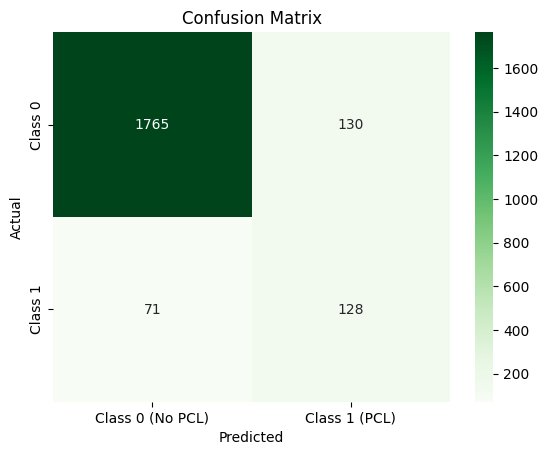

In [39]:
dev_df = pd.read_csv("train_data/dev_set.csv")
true_labels = dev_df["label"].values
with open("Predictions/dev.txt", "r") as f:
    preds = [int(line.strip()) for line in f]

preds = np.array(preds)
f1 = f1_score(true_labels, preds, pos_label=1)
print("Positive Class F1:", f1)

print(classification_report(true_labels, preds))

# Confusion matrix
c_matrix = confusion_matrix(true_labels, preds)
sns.heatmap(c_matrix, annot=True, fmt="d", cmap="Greens", xticklabels=["Class 0 (No PCL)", "Class 1 (PCL)"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()